#MLP Neural Netowrk Forward Pass

In [ ]:
import torch
import torch.nn as nn

class FCNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                # (B, 1, 28, 28) → (B, 784)
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()                 # probability in [0, 1]
        )

    def forward(self, x):
        return self.net(x)


#MLP Neural network defining train and test function


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_model(
    train_loader,
    device="cpu",
    lr=1e-3,
    num_epochs=10
):
    # initialize model
    model = FCNet().to(device)

    # loss + optimizer
    criterion = nn.BCELoss()  # model outputs probabilities
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for x, y in train_loader:
            x = x.to(device)          # (B, 1, 28, 28)
            y = y.to(device).float()  # (B,) or (B, 1)

            optimizer.zero_grad()

            preds = model(x).squeeze(1)  # (B,)
            loss = criterion(preds, y)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * x.size(0)

        epoch_loss /= len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f}")

    return model


#iNITIALISE MNIST DATASET

In [ ]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

def make_mnist_loaders(
    data_dir="./data",
    batch_size=128,
    test_batch_size=256,
    train_split=0.9,
    num_workers=2,
    seed=42
):
    tfm = transforms.Compose([
        transforms.ToTensor(),  # -> (1, 28, 28) in [0,1]
    ])

    # full train set (60k) + test set (10k)
    train_full = datasets.MNIST(root=data_dir, train=True, download=True, transform=tfm)
    test_set   = datasets.MNIST(root=data_dir, train=False, download=True, transform=tfm)

    # train/val split from the 60k
    n_total = len(train_full)
    n_train = int(n_total * train_split)
    n_val   = n_total - n_train

    g = torch.Generator().manual_seed(seed)
    train_set, val_set = random_split(train_full, [n_train, n_val], generator=g)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_set, batch_size=test_batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_set, batch_size=test_batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, test_loader

device = "cuda" if torch.cuda.is_available() else "cpu"
train_loader, val_loader, test_loader = make_mnist_loaders()
model = train_model(train_loader, device=device, lr=1e-3, num_epochs=10)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.62MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


RuntimeError: all elements of target should be between 0 and 1

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.5MB/s]


Epoch 1/5 | loss=0.3453 | test_acc=95.13%
Epoch 2/5 | loss=0.1274 | test_acc=96.44%
Epoch 3/5 | loss=0.0856 | test_acc=97.42%
Epoch 4/5 | loss=0.0617 | test_acc=97.30%
Epoch 5/5 | loss=0.0477 | test_acc=97.70%


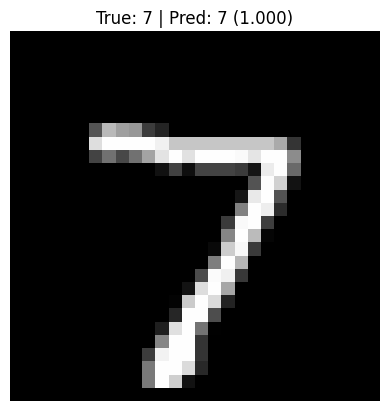

Class probabilities:
tensor([3.1266e-07, 1.3061e-07, 9.6133e-05, 3.3892e-04, 2.3943e-09, 1.4180e-07,
        2.3258e-14, 9.9953e-01, 1.5493e-05, 1.9457e-05])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# -----------------------------
# 1) MNIST loaders
# -----------------------------
def make_mnist_loaders(data_dir="./data", batch_size=128, test_batch_size=256, num_workers=2):
    tfm = transforms.ToTensor()
    train_set = datasets.MNIST(root=data_dir, train=True, download=True, transform=tfm)
    test_set  = datasets.MNIST(root=data_dir, train=False, download=True, transform=tfm)

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_set, batch_size=test_batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    return train_loader, test_loader


# -----------------------------
# 2) Classic MLP for MNIST (10 classes)
# -----------------------------
class MLP(nn.Module):
    def __init__(self, hidden1=256, hidden2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                 # (B,1,28,28) -> (B,784)
            nn.Linear(28 * 28, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 10)        # logits for 10 classes
        )

    def forward(self, x):
        return self.net(x)


# -----------------------------
# 3) Train + Eval (accuracy)
# -----------------------------
@torch.no_grad()
def evaluate(model, loader, device="cpu"):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.numel()
    return correct / total


def train_mlp(train_loader, test_loader, device="cpu", lr=1e-3, epochs=5):
    model = MLP().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for ep in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        test_acc = evaluate(model, test_loader, device=device)
        print(f"Epoch {ep}/{epochs} | loss={train_loss:.4f} | test_acc={test_acc*100:.2f}%")

    return model


# -----------------------------
# 4) Visualise one test case
# -----------------------------
@torch.no_grad()
def show_test_case(model, test_loader, device="cpu", index_in_batch=0):
    model.eval()

    x, y = next(iter(test_loader))  # one batch
    x, y = x.to(device), y.to(device)

    logits = model(x)
    probs = torch.softmax(logits, dim=1)

    true_label = y[index_in_batch].item()
    pred_label = probs[index_in_batch].argmax().item()
    pred_prob  = probs[index_in_batch, pred_label].item()

    img = x[index_in_batch].squeeze(0).detach().cpu().numpy()

    plt.figure()
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"True: {true_label} | Pred: {pred_label} ({pred_prob:.3f})")
    plt.show()

    # optional: print class probabilities
    print("Class probabilities:")
    print(probs[index_in_batch].detach().cpu())


# -----------------------------
# 5) Run it
# -----------------------------
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_loader, test_loader = make_mnist_loaders(batch_size=128, test_batch_size=256)
    model = train_mlp(train_loader, test_loader, device=device, lr=1e-3, epochs=5)

    show_test_case(model, test_loader, device=device, index_in_batch=0)


# bASIC CNN FORWARD PASS

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # convolutional feature extractor
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 28x28 -> 28x28
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 28x28 -> 28x28
        self.pool  = nn.MaxPool2d(2, 2)                           # 28x28 -> 14x14

        # classifier
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # x: (B, 1, 28, 28)
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))   # (B, 64, 14, 14)

        x = x.view(x.size(0), -1)               # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)                         # logits
        return x


#full cNN

Epoch 1/5 | loss=0.1801 | test_acc=98.42%
Epoch 2/5 | loss=0.0454 | test_acc=98.78%
Epoch 3/5 | loss=0.0292 | test_acc=98.93%
Epoch 4/5 | loss=0.0193 | test_acc=98.85%
Epoch 5/5 | loss=0.0150 | test_acc=98.78%


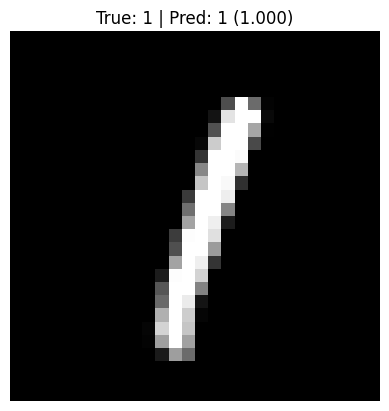

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# =========================
# 1) MNIST DATA LOADERS
# =========================
def make_mnist_loaders(
    data_dir="./data",
    batch_size=128,
    test_batch_size=256,
    num_workers=2
):
    transform = transforms.ToTensor()

    train_set = datasets.MNIST(
        root=data_dir, train=True, download=True, transform=transform
    )
    test_set = datasets.MNIST(
        root=data_dir, train=False, download=True, transform=transform
    )

    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=True
    )
    test_loader = DataLoader(
        test_set, batch_size=test_batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=True
    )

    return train_loader, test_loader


# =========================
# 2) BASIC CNN MODEL
# =========================
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)   # 28x28
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1) # 28x28
        self.pool  = nn.MaxPool2d(2, 2)              # 14x14

        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)  # logits


# =========================
# 3) EVALUATION (ACCURACY)
# =========================
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return correct / total


# =========================
# 4) TRAINING LOOP
# =========================
def train_cnn(
    train_loader,
    test_loader,
    device="cpu",
    lr=1e-3,
    epochs=5
):
    model = BasicCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        test_acc = evaluate(model, test_loader, device)

        print(
            f"Epoch {epoch}/{epochs} | "
            f"loss={train_loss:.4f} | "
            f"test_acc={test_acc*100:.2f}%"
        )

    return model


# =========================
# 5) VISUALISE TEST SAMPLE
# =========================
@torch.no_grad()
def show_test_case(model, test_loader, device, idx=0):
    model.eval()

    x, y = next(iter(test_loader))
    x, y = x.to(device), y.to(device)

    logits = model(x)
    probs = torch.softmax(logits, dim=1)

    true_label = y[idx].item()
    pred_label = probs[idx].argmax().item()
    confidence = probs[idx, pred_label].item()

    img = x[idx].squeeze(0).cpu().numpy()

    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"True: {true_label} | Pred: {pred_label} ({confidence:.3f})")
    plt.show()


# =========================
# 6) RUN EVERYTHING
# =========================
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"

    train_loader, test_loader = make_mnist_loaders()
    model = train_cnn(
        train_loader,
        test_loader,
        device=device,
        lr=1e-3,
        epochs=5
    )

    show_test_case(model, test_loader, device, idx=5)
